# Per-wavenumber memorization in SongUNet on rescaled Matern fieldsRing-ratio metric (coarse NN, per-band relative L2) for SongUNet trained onrescaled Matern fields at n_train=2, over model capacities C=4,8,16,32.Checkpoints at every 1000 epochs from 1k to 50k.Conventions: `exclude_nn=True`, `aggregate="mean_of_ratios"`,bands: coarse (0.5,4), mid1 (4,10), mid2 (10,18), fine (18,32).

In [1]:
import os, sys
import numpy as np
import torch
import matplotlib
if not os.environ.get('DISPLAY') and not hasattr(sys, 'ps1'):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from device_utils import resolve_device
from memorization_metrics import RingMetricContext

DEVICE = resolve_device()
print(f'device: {DEVICE}')

# -- band definitions (locked) --
BANDS = {'coarse': (0.5, 4), 'mid1': (4, 10), 'mid2': (10, 18), 'fine': (18, 32)}
BAND_NAMES = list(BANDS.keys())

# -- load result files --
data_dir = os.path.join(repo_root, 'results', 'data', 'baptista_matern_n2')
capacities = [4, 8, 16, 32]
results = {}
for c in capacities:
    path = os.path.join(data_dir, f'arm_rescaled_c{c}_result.pt')
    results[c] = torch.load(path, map_location='cpu', weights_only=False)
    print(f'C={c}: {len(results[c]['eval_log'])} checkpoints, '
          f'n_params={results[c]['n_params']}, '
          f'epochs {results[c]['eval_log'][0]['epoch']}-{results[c]['eval_log'][-1]['epoch']}')

device: mps
C=4: 50 checkpoints, n_params=57017, epochs 1000-50000
C=8: 50 checkpoints, n_params=222705, epochs 1000-50000
C=16: 50 checkpoints, n_params=880097, epochs 1000-50000
C=32: 50 checkpoints, n_params=3498945, epochs 1000-50000


In [2]:
# Compute per-band ring ratios for all checkpoints x capacities
ctx = RingMetricContext(N=128, bands=BANDS, device=DEVICE)

# scores[c] = dict with 'epochs' and per-band arrays, each shape (n_checkpoints,)
scores = {}

for c in capacities:
    el = results[c]['eval_log']
    x_train = results[c]['data'].squeeze(1).to(DEVICE)  # (2, 128, 128)

    epochs_list = []
    band_scores = {b: [] for b in BAND_NAMES}

    for entry in el:
        ep = entry['epoch']
        x_gen = entry['samples'].squeeze(1).to(DEVICE)  # (16, 128, 128)

        out = ctx.evaluate(x_gen, x_train, n_rand_ref=32, exclude_nn=True,
                           aggregate='mean_of_ratios')

        epochs_list.append(ep)
        for b in BAND_NAMES:
            band_scores[b].append(out[f'{b}_score'].mean().item())

    scores[c] = {
        'epochs': np.array(epochs_list),
        **{b: np.array(band_scores[b]) for b in BAND_NAMES}
    }
    print(f'C={c}: done ({len(epochs_list)} checkpoints)')

print('All capacities computed.')

C=4: done (50 checkpoints)


C=8: done (50 checkpoints)


C=16: done (50 checkpoints)


C=32: done (50 checkpoints)
All capacities computed.


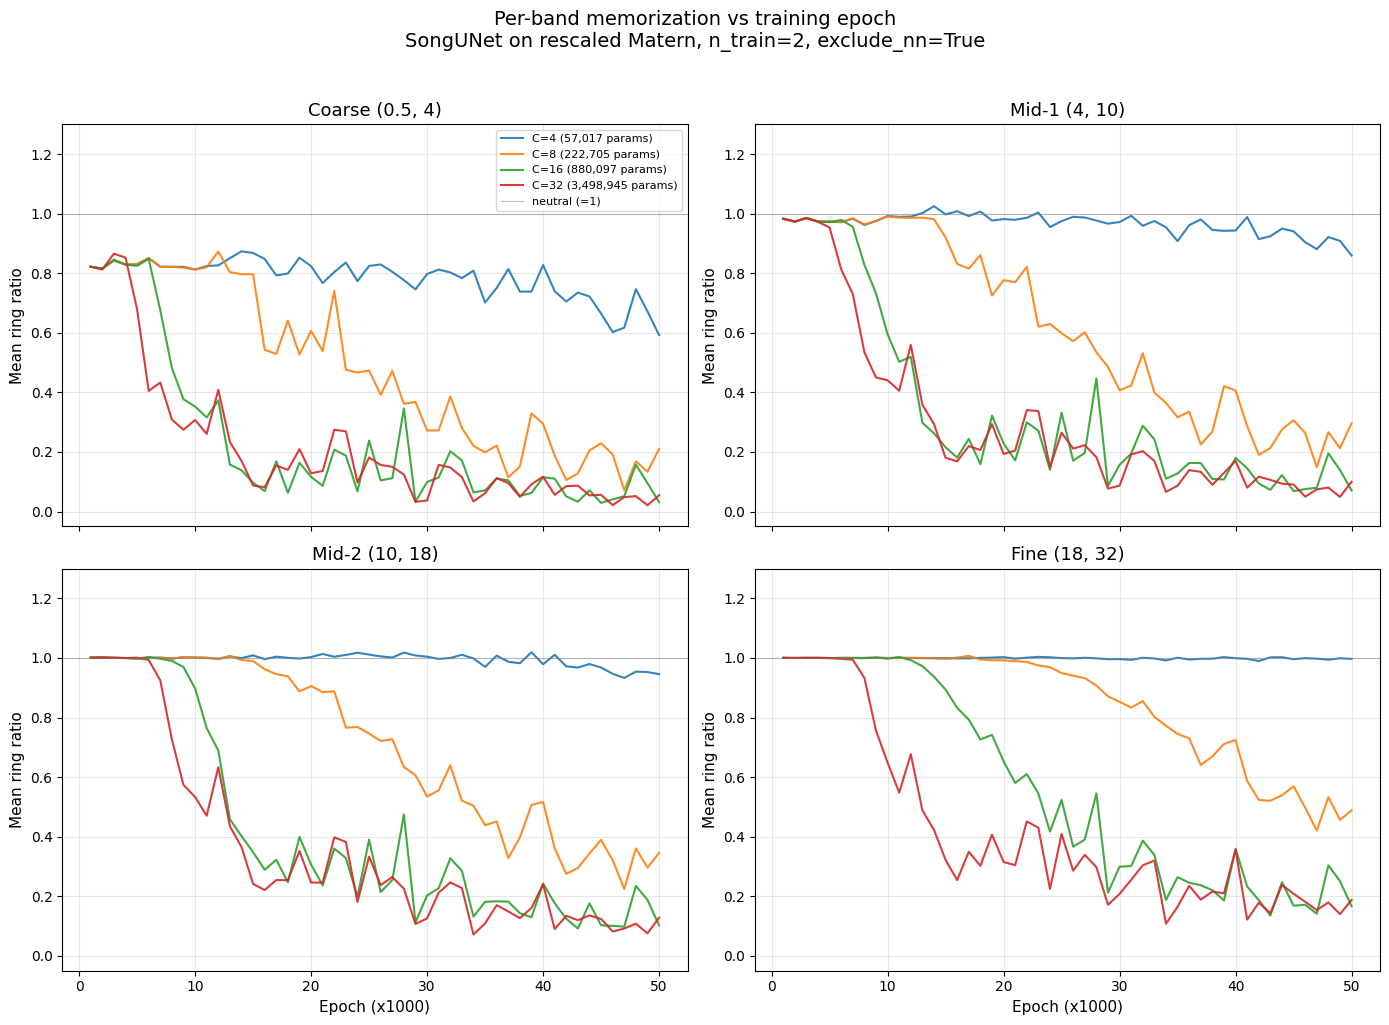

In [3]:
# Figure 1: Per-band memorization score vs training epoch
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

colors = {4: '#1f77b4', 8: '#ff7f0e', 16: '#2ca02c', 32: '#d62728'}
band_labels = {'coarse': 'Coarse (0.5, 4)', 'mid1': 'Mid-1 (4, 10)',
               'mid2': 'Mid-2 (10, 18)', 'fine': 'Fine (18, 32)'}

for i, band in enumerate(BAND_NAMES):
    ax = axes[i]
    for c in capacities:
        ax.plot(scores[c]['epochs'] / 1000, scores[c][band],
                color=colors[c], label=f'C={c} ({results[c]['n_params']:,} params)',
                linewidth=1.5, alpha=0.9)

    ax.axhline(1.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='neutral (=1)')
    ax.set_title(band_labels[band], fontsize=13)
    ax.set_ylabel('Mean ring ratio', fontsize=11)
    ax.set_ylim(-0.05, 1.3)
    ax.grid(True, alpha=0.3)

    if i >= 2:
        ax.set_xlabel('Epoch (x1000)', fontsize=11)

axes[0].legend(fontsize=8, loc='upper right')

fig.suptitle('Per-band memorization vs training epoch\n'
             'SongUNet on rescaled Matern, n_train=2, exclude_nn=True',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

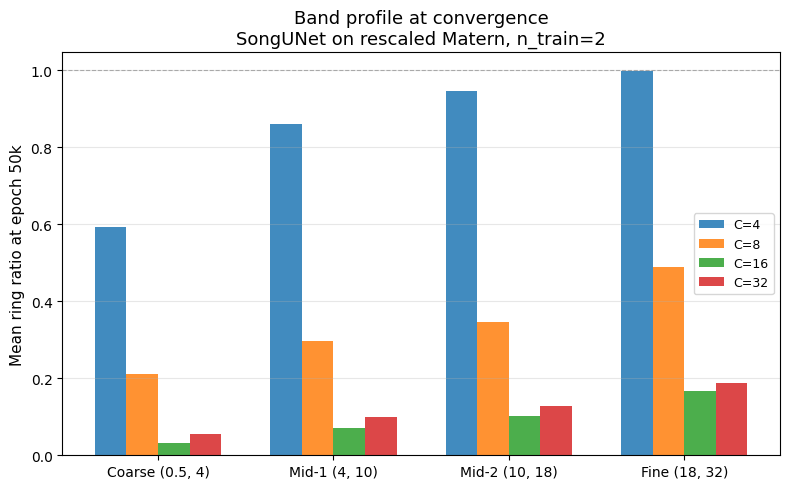

In [4]:
# Figure 2: Band profile at final checkpoint (epoch 50000)
fig, ax = plt.subplots(figsize=(8, 5))

band_positions = np.arange(len(BAND_NAMES))
bar_width = 0.18

for j, c in enumerate(capacities):
    final_scores = [scores[c][b][-1] for b in BAND_NAMES]
    ax.bar(band_positions + j * bar_width, final_scores, bar_width,
           color=colors[c], label=f'C={c}', alpha=0.85)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xticks(band_positions + 1.5 * bar_width)
ax.set_xticklabels([band_labels[b] for b in BAND_NAMES], fontsize=10)
ax.set_ylabel('Mean ring ratio at epoch 50k', fontsize=11)
ax.set_title('Band profile at convergence\n'
             'SongUNet on rescaled Matern, n_train=2',
             fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

/var/folders/8l/6c46f7fj2xb98klnfc5qlync0000gn/T/ipykernel_77045/580022508.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


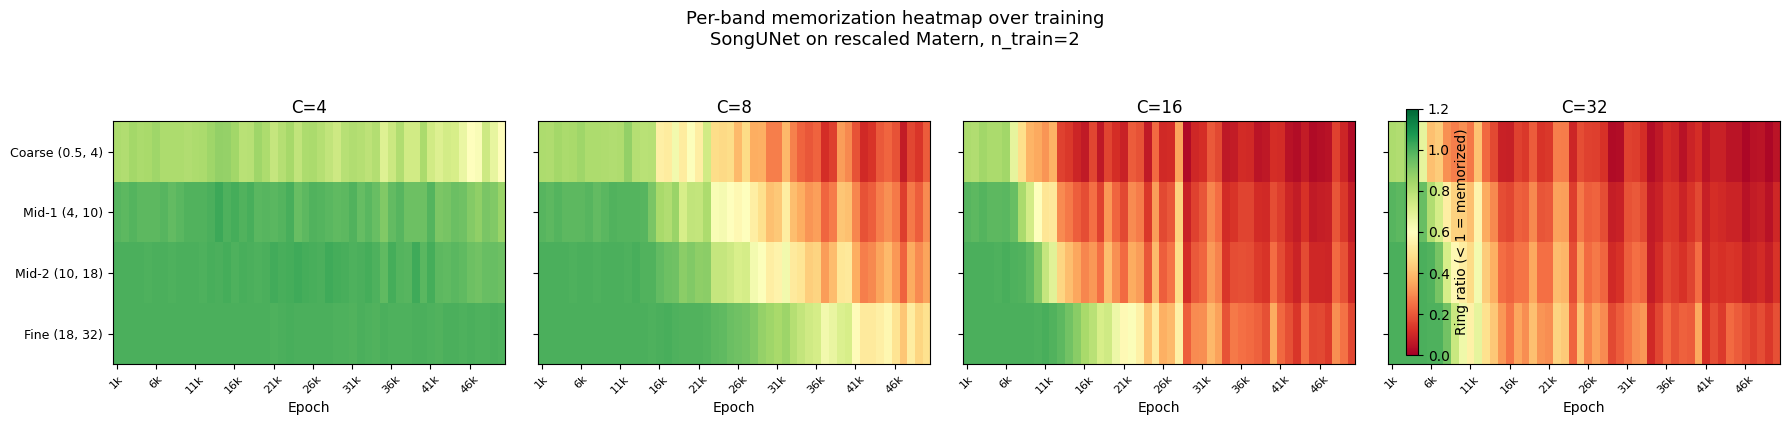

In [5]:
# Figure 3: Heatmap of per-band memorization over training
# Show all four capacities
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for j, c in enumerate(capacities):
    # Build matrix: rows=bands, cols=epochs
    mat = np.array([scores[c][b] for b in BAND_NAMES])  # (4, n_epochs)
    epochs = scores[c]['epochs']

    # Subsample epoch labels for readability
    n_ep = len(epochs)
    tick_step = max(1, n_ep // 10)
    tick_idx = list(range(0, n_ep, tick_step))

    im = axes[j].imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1.2,
                         interpolation='nearest')
    axes[j].set_title(f'C={c}', fontsize=12)
    axes[j].set_xticks(tick_idx)
    axes[j].set_xticklabels([f'{int(epochs[k]/1000)}k' for k in tick_idx],
                             rotation=45, fontsize=8)
    axes[j].set_xlabel('Epoch', fontsize=10)

axes[0].set_yticks(range(len(BAND_NAMES)))
axes[0].set_yticklabels([band_labels[b] for b in BAND_NAMES], fontsize=9)

fig.colorbar(im, ax=axes, shrink=0.8, label='Ring ratio (< 1 = memorized)')
fig.suptitle('Per-band memorization heatmap over training\n'
             'SongUNet on rescaled Matern, n_train=2',
             fontsize=13, y=1.05)
fig.tight_layout()
plt.show()

In [6]:
# Save figures
fig_dir = os.path.join(repo_root, 'results', 'figures')
os.makedirs(fig_dir, exist_ok=True)

# Re-create and save Figure 1
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes1 = axes1.flatten()
for i, band in enumerate(BAND_NAMES):
    ax = axes1[i]
    for c in capacities:
        ax.plot(scores[c]['epochs'] / 1000, scores[c][band],
                color=colors[c], label=f'C={c} ({results[c]['n_params']:,} params)',
                linewidth=1.5, alpha=0.9)
    ax.axhline(1.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5, label='neutral (=1)')
    ax.set_title(band_labels[band], fontsize=13)
    ax.set_ylabel('Mean ring ratio', fontsize=11)
    ax.set_ylim(-0.05, 1.3)
    ax.grid(True, alpha=0.3)
    if i >= 2:
        ax.set_xlabel('Epoch (x1000)', fontsize=11)
axes1[0].legend(fontsize=8, loc='upper right')
fig1.suptitle('Per-band memorization vs training epoch\n'
              'SongUNet on rescaled Matern, n_train=2, exclude_nn=True',
              fontsize=14, y=1.02)
fig1.tight_layout()
fig1.savefig(os.path.join(fig_dir, 'songunet_perband_vs_epoch.png'), dpi=150, bbox_inches='tight')
plt.close(fig1)

# Re-create and save Figure 2
fig2, ax2 = plt.subplots(figsize=(8, 5))
band_positions = np.arange(len(BAND_NAMES))
for j, c in enumerate(capacities):
    final_scores = [scores[c][b][-1] for b in BAND_NAMES]
    ax2.bar(band_positions + j * bar_width, final_scores, bar_width,
            color=colors[c], label=f'C={c}', alpha=0.85)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_xticks(band_positions + 1.5 * bar_width)
ax2.set_xticklabels([band_labels[b] for b in BAND_NAMES], fontsize=10)
ax2.set_ylabel('Mean ring ratio at epoch 50k', fontsize=11)
ax2.set_title('Band profile at convergence\nSongUNet on rescaled Matern, n_train=2', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig(os.path.join(fig_dir, 'songunet_perband_profile.png'), dpi=150, bbox_inches='tight')
plt.close(fig2)

# Re-create and save Figure 3
fig3, axes3 = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for j, c in enumerate(capacities):
    mat = np.array([scores[c][b] for b in BAND_NAMES])
    epochs = scores[c]['epochs']
    n_ep = len(epochs)
    tick_step = max(1, n_ep // 10)
    tick_idx = list(range(0, n_ep, tick_step))
    im = axes3[j].imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1.2,
                          interpolation='nearest')
    axes3[j].set_title(f'C={c}', fontsize=12)
    axes3[j].set_xticks(tick_idx)
    axes3[j].set_xticklabels([f'{int(epochs[k]/1000)}k' for k in tick_idx],
                              rotation=45, fontsize=8)
    axes3[j].set_xlabel('Epoch', fontsize=10)
axes3[0].set_yticks(range(len(BAND_NAMES)))
axes3[0].set_yticklabels([band_labels[b] for b in BAND_NAMES], fontsize=9)
fig3.colorbar(im, ax=axes3, shrink=0.8, label='Ring ratio (< 1 = memorized)')
fig3.suptitle('Per-band memorization heatmap over training\nSongUNet on rescaled Matern, n_train=2',
              fontsize=13, y=1.05)
fig3.tight_layout()
fig3.savefig(os.path.join(fig_dir, 'songunet_perband_heatmap.png'), dpi=150, bbox_inches='tight')
plt.close(fig3)

print('Saved:')
print(f'  {os.path.join(fig_dir, "songunet_perband_vs_epoch.png")}')
print(f'  {os.path.join(fig_dir, "songunet_perband_profile.png")}')
print(f'  {os.path.join(fig_dir, "songunet_perband_heatmap.png")}')

Saved:
  /Users/ishittaiyer/Desktop/research-diffusion/results/figures/songunet_perband_vs_epoch.png
  /Users/ishittaiyer/Desktop/research-diffusion/results/figures/songunet_perband_profile.png
  /Users/ishittaiyer/Desktop/research-diffusion/results/figures/songunet_perband_heatmap.png


/var/folders/8l/6c46f7fj2xb98klnfc5qlync0000gn/T/ipykernel_77045/956441605.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig3.tight_layout()
